# Кейс 7 Обученная модель бинарной классификации, определяющая вероятность отказа оборудования
## Нужно предсказать, произойдёт ли отказ оборудования на основе его технических характеристик, условий эксплуатации и истории работы

- Импорт и анализ исторических данных
- Предобработка и очистка данных
- Обучение модели (SVM, деревья решений)
- Оценка метрик precision, recall, ROC-AUC

###  Участники
- Скрипин Сергей
- Яньшин Александр
- Ненилин Владислав
- Дроздюков Владимир
- Исангузин Ильдар
- Валиуллин Эдуард Римович

# Анализ структуры данных

Метод `df.info()` покажет:

## Основную информацию:
- Количество строк (наблюдений)
- Количество столбцов (признаков)
- Имена всех столбцов
- Типы данных каждого столбца (int64, float64, object и т.д.)
- Количество non-null значений в каждом столбце
- Объем используемой памяти

## Что это даст:
- Понимание полноты данных (пропуски)
- Определение типов переменных (числовые/категориальные)
- Оценка общего размера датасета
- Выявление потенциальных проблем с типами данных

1. Загрузка train.csv и базовый просмотр

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url_train = "https://raw.githubusercontent.com/dvigatelizm/keis7/main/train.csv"
df = pd.read_csv(url_train)

print("Размер датасета:", df.shape)
print("\nСтолбцы:\n", df.columns.tolist())
df.head(10)


Размер датасета: (136429, 14)

Столбцы:
 ['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0
5,5,M24300,M,298.4,308.9,1429,42.1,65,0,0,0,0,0,0
6,6,L56736,L,299.6,311.0,1413,42.9,156,0,0,0,0,0,0
7,7,L55488,L,298.7,310.1,1609,38.1,67,0,0,0,0,0,0
8,8,L56397,L,297.7,308.8,1578,35.2,13,0,0,0,0,0,0
9,9,L55067,L,300.5,312.3,1447,53.3,98,0,0,0,0,0,0


## 2. Анализ данных

### 2.1 Проверка уникальности идентификаторов 'id' и 'Product ID'

In [14]:
print("Уникальных id:", df['id'].nunique(), "из", len(df))
print("Уникальных Product ID:", df['Product ID'].nunique())


Уникальных id: 136429 из 136429
Уникальных Product ID: 9976


### Вывод 

- id — уникальный технический идентификатор.
Он не несёт смысловой информации поэтому исключаем его из признаков.

- Product ID повторяется многократно, что указывает на наличие нескольких записей для одного оборудования.

Это важно — такие группы должны быть разнесены при разбиении данных, иначе модель «подглядит» информацию о продукте и метрики будут нечестными

### 2.2 Анализ количества строк на один Product ID

In [15]:

prod_counts = df['Product ID'].value_counts()
grouped_counts = prod_counts.value_counts().sort_index()

print("Сколько Product ID имеют одинаковое число строк")
for number_of_rows, how_many_products in grouped_counts.items():
    print(f"Объект с {number_of_rows} строками: {how_many_products}")

Сколько Product ID имеют одинаковое число строк
Объект с 1 строками: 85
Объект с 2 строками: 196
Объект с 3 строками: 295
Объект с 4 строками: 450
Объект с 5 строками: 547
Объект с 6 строками: 625
Объект с 7 строками: 636
Объект с 8 строками: 633
Объект с 9 строками: 616
Объект с 10 строками: 654
Объект с 11 строками: 567
Объект с 12 строками: 530
Объект с 13 строками: 458
Объект с 14 строками: 431
Объект с 15 строками: 375
Объект с 16 строками: 346
Объект с 17 строками: 280
Объект с 18 строками: 238
Объект с 19 строками: 214
Объект с 20 строками: 188
Объект с 21 строками: 171
Объект с 22 строками: 147
Объект с 23 строками: 115
Объект с 24 строками: 140
Объект с 25 строками: 116
Объект с 26 строками: 86
Объект с 27 строками: 64
Объект с 28 строками: 67
Объект с 29 строками: 69
Объект с 30 строками: 53
Объект с 31 строками: 37
Объект с 32 строками: 40
Объект с 33 строками: 34
Объект с 34 строками: 34
Объект с 35 строками: 28
Объект с 36 строками: 24
Объект с 37 строками: 21
Объект с 38 

### Визуализация распределения количества записей на один продукт

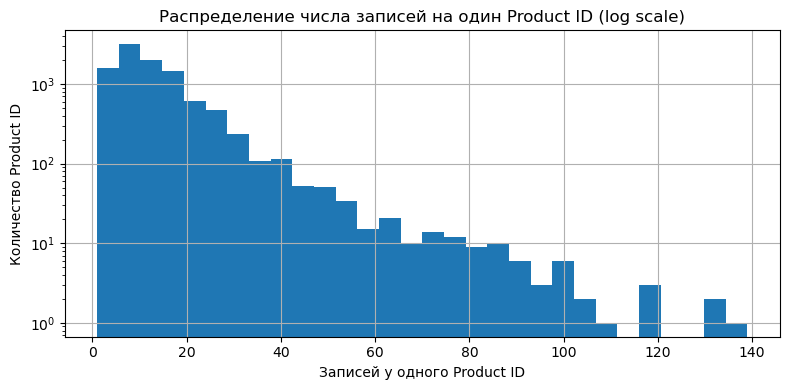

In [16]:
plt.figure(figsize=(8,4))
prod_counts.hist(bins=30)
plt.yscale('log')
plt.title("Распределение числа записей на один Product ID (log scale)")
plt.xlabel("Записей у одного Product ID")
plt.ylabel("Количество Product ID")
plt.tight_layout()
plt.savefig("productid_repeat_hist.png", dpi=150)
plt.show()


### Вывод 

- Большинство Product ID встречаются несколько раз, а не один.

- Это означает, что строки внутри одного Product ID коррелируют между собой.
 Чтобы избежать утечки информации при обучении, нужно использовать GroupShuffleSplit по Product ID.
Это важнейшее основание для корректного формирования выборок.

### 2.3 Анализ целевой переменной Machine failure

Machine failure
0    134281
1      2148
Name: count, dtype: int64


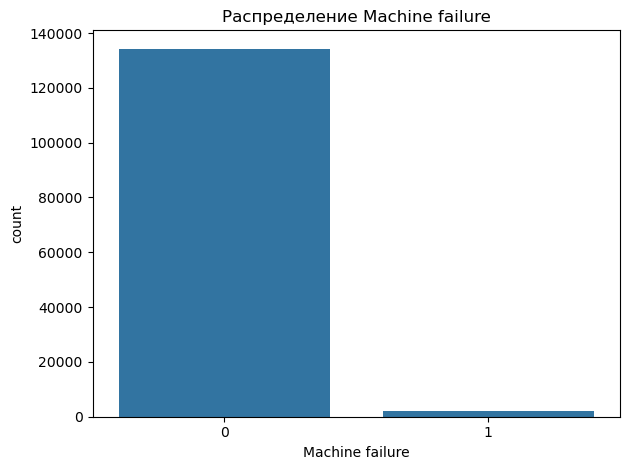

In [17]:
print(df['Machine failure'].value_counts())
sns.countplot(x='Machine failure', data=df)
plt.title("Распределение Machine failure")
plt.tight_layout()
plt.savefig("machine_failure_count.png", dpi=150)
plt.show()



## Вывод
- Класс «нет отказа» — 98.43%
- Класс «отказ» — 1.57%

### Датасет несбалансирован.

Выводы:
Нужна балансировка так как при обучении модель будет думать что отказов почти нет и всегда говорить 0

На первом этапе предлагаем использовать SMOTE Потому что это самый простой и быстрый способ


### 2.4 Анализ флагов (TWF, HDF, PWF, OSF, RNF)

#### 2.4.1 Корреляция между флагами отказа и целевой функцией

In [18]:
# Список флагов
flags = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# True Positive: хотя бы один флаг = 1 и Machine failure = 1
tp_flags = df[(df[flags].sum(axis=1) > 0) & (df['Machine failure'] == 1)].shape[0]

# False Positive: хотя бы один флаг = 1, но Machine failure = 0
leak_fp = df[(df[flags].sum(axis=1) > 0) & (df['Machine failure'] == 0)].shape[0]

# False Negative: все флаги = 0, но Machine failure = 1
leak_fn = df[(df[flags].sum(axis=1) == 0) & (df['Machine failure'] == 1)].shape[0]

# Всего отказов
total_failures = df[df['Machine failure'] == 1].shape[0]

# Процент корректных сигналов
tp_percent = tp_flags / total_failures * 100

print("Случаи, когда хотя бы один флаг = 1, но Machine failure = 0 (утечка):", leak_fp)
print("Случаи, когда все флаги (TWF, HDF, PWF, OSF, RNF) равны 0, а Machine failure = 1 (пропущенные сигналы):", leak_fn)
print(f"Процент корректных сигналов флагов среди всех отказов: {tp_percent:.2f}%")
print(f"Сигналов отказов всего: {total_failures}")


Случаи, когда хотя бы один флаг = 1, но Machine failure = 0 (утечка): 315
Случаи, когда все флаги (TWF, HDF, PWF, OSF, RNF) равны 0, а Machine failure = 1 (пропущенные сигналы): 507
Процент корректных сигналов флагов среди всех отказов: 76.40%
Сигналов отказов всего: 2148


- Случаи, когда хотя бы один флаг = 1, но Machine failure = 0 (утечка): 315  
говорит нам о том что у нас 315 случаев нарушения логики 

- Случаи, когда все флаги (TWF, HDF, PWF, OSF, RNF) равны 0,  
 а Machine failure = 1 (пропущенные сигналы):   507  

#### 2.4.2 Разберемся случаев нарушения логики огда хотя бы один флаг = 1, но Machine failure = 0




     Leak count
RNF         302
HDF           6
OSF           4
PWF           3
TWF           0


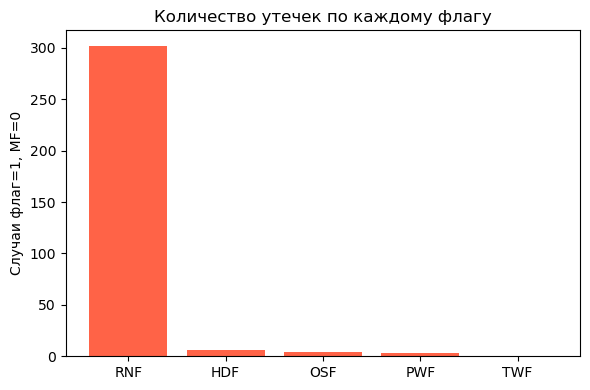

In [19]:
# Список флагов
flags = ['TWF','HDF','PWF','OSF','RNF']

# Создаём DataFrame для утечек
leak_per_flag = {}

for f in flags:
    leak_count = df[(df[f]==1) & (df['Machine failure']==0)].shape[0]
    leak_per_flag[f] = leak_count

leak_df = pd.DataFrame.from_dict(leak_per_flag, orient='index', columns=['Leak count'])
leak_df = leak_df.sort_values(by='Leak count', ascending=False)
print(leak_df)

# Визуализация
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(leak_df.index, leak_df['Leak count'], color='tomato')
plt.title("Количество утечек по каждому флагу")
plt.ylabel("Случаи флаг=1, MF=0")
plt.tight_layout()
plt.show()


#### Вывод флаг RNF подлежит удалению

## Случаи, когда все флаги равны 0,  а Machine failure = 1: 
После анализа мы видим:  
Есть пропущенные сигналы: 507 записей, где все флаги = 0, а Machine failure = 1.  
То есть флаги не полностью детерминируют отказ, часть отказов не зафиксирована флагами.  

### Вывод:

Удалять флаги полностью нежелательно, потому что они содержат полезную информацию о реальных отказах.  

Но при этом мы понимаем, что флаги создают некий шум,  
Есть ложные срабатывания (Machine failure = 0, флаг = 1) от основной массы которых мы избавимся удалив флаг RNF   



## Чтобы понять оставляем ли мы Type Проверим долю отказов для каждого типа:

In [20]:
df.groupby('Type')['Machine failure'].mean()


Type
H    0.013000
L    0.016727
M    0.013592
Name: Machine failure, dtype: float64

Это значит, что Type практически не влияет на вероятность отказа. поэтому можем его удалить

# Шаг 3. Подготовка clean-датасета

## 3.1. Удаление утечки и лишних колонок

- Убираем флаг отказов:  RNF — чтобы избежать ложных сробатываний.
- Убираем id из train (но сохраняем для test, чтобы потом вернуть предсказания).
- Так как Type практически не влияет, можно не использовать этот признак.
- Product ID можно оставить как категорию для разбиения на группы при кросс-валидации.

## 3.2. Разбиение train на train/validation

- Используем GroupShuffleSplit по Product ID, чтобы записи одного продукта не оказались одновременно в train и validation.

- Это важно, чтобы модель не видела "одинаковые продукты" в обучении и в проверке, иначе будет утечка.

## 3.3. Масштабирование числовых признаков

- Числовые признаки:  
Air temperature [K]  
Process temperature [K]  
Rotational speed [rpm]  
Torque [Nm]  
Tool wear [min]  

- Для SVM — обязательно нормализовать (StandardScaler).

- Для деревьев масштабирование не требуется, но можно для единообразия.

## 3.4. Итоговый набор признаков для модели

- Целевой: Machine failure

- Признаки: числовые технологические параметры

- Категории: Product ID — для разбиения на группы в кросс-валидации

- Удалено: id, флаг отказов RNF, Type (опционально)

In [ ]:
import pandas as pd 
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ===== 1. Убираем шумный флаг RNF, ID и Type =====
drop_cols = ['id', 'RNF', 'Type']  # оставляем TWF, HDF, PWF, OSF
df_clean = df.drop(columns=drop_cols)

# ===== 2. Разделяем на признаки и целевой =====
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

# ===== 3. Разделяем на train/validation по Product ID =====
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=df['Product ID']))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

# ===== 4. Масштабирование числовых признаков =====
num_cols = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

# ===== 5. Убираем Product ID перед SVM =====
X_train_svm = X_train.drop(columns=['Product ID'])
X_val_svm = X_val.drop(columns=['Product ID'])

# ===== 6. SVM =====
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_svm, y_train)

y_val_pred_svm = svm_model.predict(X_val_svm)
y_val_proba_svm = svm_model.predict_proba(X_val_svm)[:,1]

precision_svm = precision_score(y_val, y_val_pred_svm)
recall_svm = recall_score(y_val, y_val_pred_svm)
f1_svm = f1_score(y_val, y_val_pred_svm)
roc_auc_svm = roc_auc_score(y_val, y_val_proba_svm)

print("=== SVM ===")
print("Precision (доля правильных положительных прогнозов среди всех предсказанных):", precision_score(y_val, y_val_pred_svm))
print("Recall доля реально положительных объектов была правильно найдена моделью:", recall_score(y_val, y_val_pred_svm))
print("F1 насколько модель в целом хорошо справляется с положительным классом:", f1_score(y_val, y_val_pred_svm))
print("ROC-AUC как модель балансирует между полнотой и ошибками на отрицательном классе:", roc_auc_score(y_val, y_val_proba_svm))
print("Confusion matrix:\n", confusion_matrix(y_val, y_val_pred_svm))

# ===== 7. Decision Tree =====
X_train_dt = X_train.drop(columns=['Product ID'])
X_val_dt = X_val.drop(columns=['Product ID'])

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dt, y_train)

y_val_pred_dt = dt_model.predict(X_val_dt)
y_val_proba_dt = dt_model.predict_proba(X_val_dt)[:,1]

precision_dt = precision_score(y_val, y_val_pred_dt)
recall_dt = recall_score(y_val, y_val_pred_dt)
f1_dt = f1_score(y_val, y_val_pred_dt)
roc_auc_dt = roc_auc_score(y_val, y_val_proba_dt)

print("\n=== Decision Tree ===")
print("Precision (доля правильных положительных прогнозов среди всех предсказанных):", precision_score(y_val, y_val_pred_dt))
print("Recall доля реально положительных объектов была правильно найдена моделью:", recall_score(y_val, y_val_pred_dt))
print("F1 насколько модель в целом хорошо справляется с положительным классом:", f1_score(y_val, y_val_pred_dt))
print("ROC-AUC как модель балансирует между полнотой и ошибками на отрицательном классе:", roc_auc_score(y_val, y_val_proba_dt))
print("Confusion matrix как модель распределила объекты по правильным и неправильным классам.:\n", confusion_matrix(y_val, y_val_pred_dt))


# ===== 8. Сравнение моделей =====
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
svm_scores = [precision_svm, recall_svm, f1_svm, roc_auc_svm]
dt_scores = [precision_dt, recall_dt, f1_dt, roc_auc_dt]

print("\n=== Сравнение моделей ===")
for metric, svm_score, dt_score in zip(metrics, svm_scores, dt_scores):
    better = "SVM" if svm_score > dt_score else "Decision Tree" if dt_score > svm_score else "Одинаково"
    print(f"{metric}: SVM = {svm_score:.3f}, Decision Tree = {dt_score:.3f} → Лучшая модель: {better}")

In [1]:
print("=== SVM ===")
print("Precision ):", precision_score(y_val, y_val_pred_svm))
print("Recall :", recall_score(y_val, y_val_pred_svm))
print("F1 ", f1_score(y_val, y_val_pred_svm))
print("ROC-AUC ", roc_auc_score(y_val, y_val_proba_svm))
print("Confusion matrix:\n", confusion_matrix(y_val, y_val_pred_svm))

print("\n=== Decision Tree ===")
print("Precision :", precision_score(y_val, y_val_pred_dt))
print("Recall ", recall_score(y_val, y_val_pred_dt))
print("F1 ", f1_score(y_val, y_val_pred_dt))
print("ROC-AUC ", roc_auc_score(y_val, y_val_proba_dt))
print("Confusion matrix :\n", confusion_matrix(y_val, y_val_pred_dt))


=== SVM ===


NameError: name 'precision_score' is not defined